In [1]:
# NBVAL_SKIP
from jax import config
#config.update("jax_enable_x64", True)
#config.update('jax_num_cpu_devices', 2)

In [2]:
#NBVAL_SKIP
import os

# Tell XLA to fake 2 host CPU devices
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=3'

# Only make GPU 0 and GPU 1 visible to JAX:
#os.environ['CUDA_VISIBLE_DEVICES'] = '1,2'

#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]   = "false"

import jax

# Now JAX will list two CpuDevice entries
print(jax.devices())
# → [CpuDevice(id=0), CpuDevice(id=1)]

[CpuDevice(id=0)]


In [3]:
# NBVAL_SKIP
import os
#os.environ['SPS_HOME'] = '/mnt/storage/annalena_data/sps_fsps'
#os.environ['SPS_HOME'] = '/home/annalena/sps_fsps'
os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
#os.environ['SPS_HOME'] = '/export/home/aschaibl/fsps'

# Load ssp template from FSPS

In [4]:
# NBVAL_SKIP
from rubix.spectra.ssp.factory import get_ssp_template
ssp_fsps = get_ssp_template("FSPS")

2025-10-07 11:43:24,691 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2025-10-07 11:43:24,691 - rubix - INFO - Rubix version: 0.0.post503+g060c53b49.d20251002
2025-10-07 11:43:24,692 - rubix - INFO - JAX version: 0.4.38
2025-10-07 11:43:24,692 - rubix - INFO - Running on [CpuDevice(id=0)] devices


In [5]:
# NBVAL_SKIP
age_values = ssp_fsps.age
print(age_values.shape)

metallicity_values = ssp_fsps.metallicity
print(metallicity_values.shape)

(107,)
(12,)


# Configure pipeline

In [6]:
# NBVAL_SKIP
from rubix.core.pipeline import RubixPipeline
import os
config = {
    "pipeline":{"name": "calc_gradient",},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "IllustrisAPI",
        "args": {
            "api_key": os.environ.get("ILLUSTRIS_API_KEY"),
            "particle_type": ["stars"],
            "simulation": "TNG50-1",
            "snapshot": 99,
            "save_data_path": "data",
        },
        
        "load_galaxy_args": {
        "id": 14,
        "reuse": True,
        },
        
        "subset": {
            "use_subset": True,
            "subset_size": 2,
        },
    },
    "simulation": {
        "name": "IllustrisTNG",
        "args": {
            "path": "data/galaxy-id-14.hdf5",
        },
    
    },
    "output_path": "output",

    "telescope":
        {"name": "TESTGRADIENT",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 1.2},
         "noise": {"signal_to_noise": 100,"noise_distribution": "normal"},
         },
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.1,
         "rotation": {"type": "edge-on"},
        },
        
    "ssp": {
        "template": {
            "name": "FSPS"
        },
        "dust": {
                "extinction_model": "Cardelli89",
                "dust_to_gas_ratio": 0.01,
                "dust_to_metals_ratio": 0.4,
                "dust_grain_density": 3.5,
                "Rv": 3.1,
            },
    },        
}

In [7]:
# NBVAL_SKIP
pipe = RubixPipeline(config)
inputdata = pipe.prepare_data()

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-10-07 11:43:25,228 - rubix - INFO - Getting rubix data...
2025-10-07 11:43:25,228 - rubix - INFO - Rubix galaxy file already exists, skipping conversion
/Users/annalena/miniconda3/envs/rubix/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:188: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)
/Users/annalena/Documents/GitHub/rubix/rubix/core/data.py:537: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and wil

# Gradient on the spectrum for each wavelenght

In [8]:
# NBVAL_SKIP
from rubix.pipeline import linear_pipeline as pipeline

pipeline_instance = RubixPipeline(config)

pipeline_instance._pipeline = pipeline.LinearTransformerPipeline(
    pipeline_instance.pipeline_config, 
    pipeline_instance._get_pipeline_functions()
)
pipeline_instance._pipeline.assemble()
pipeline_instance.func = pipeline_instance._pipeline.compile_expression()

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-10-07 11:43:25,988 - rubix - INFO - Setting up the pipeline...
2025-10-07 11:43:25,988 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_psf': {'name': 'convolve_psf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'convolve_psf', 'args': [], 'kwargs': {}}, 'apply_noise': {'name': 'apply_noise', 'depends_on': 'convolve_lsf',

In [9]:
# pick values
initial_age_index = 100
initial_metallicity_index = 5
age0 = age_values[initial_age_index]
Z0   = metallicity_values[initial_metallicity_index]

In [10]:
print(f"age0 = {age0}, Z0 = {Z0}")

age0 = 10.0, Z0 = 0.001420000335201621


In [11]:
# NBVAL_SKIP
import jax.numpy as jnp

inputdata.stars.age = jnp.array([age_values[initial_age_index], age_values[initial_age_index]])
inputdata.stars.metallicity = jnp.array([metallicity_values[initial_metallicity_index], metallicity_values[initial_metallicity_index]])
inputdata.stars.mass = jnp.array([[1.0], [1.0]])
inputdata.stars.velocity = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
inputdata.stars.coords = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])

In [12]:
import dataclasses
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def spectrum_1d(age, Z, base_data, pipeline_instance):
    # broadcast per-star
    nstar = base_data.stars.age.shape[0]
    stars2 = dataclasses.replace(
        base_data.stars,
        age=jnp.full((nstar,), age),
        metallicity=jnp.full((nstar,), Z),
    )
    data2 = dataclasses.replace(base_data, stars=stars2)

    out = pipeline_instance.func(data2)

    cube = out.stars.datacube                        # shape (…, n_lambda)
    # collapse all non-wavelength axes, keep wavelength last
    spec = cube.reshape((-1, cube.shape[-1])).sum(axis=0)

    return jnp.ravel(spec)   

In [13]:
f = lambda a: spectrum_1d(a, Z0, inputdata, pipeline_instance)
ds_jvp = jax.jvp(f, (age0,), (1.0,))[1]
ds_fwd = jax.jacfwd(f)(age0)
print("||jvp - jacfwd|| =", jnp.linalg.norm(ds_jvp - ds_fwd))


2025-10-07 11:43:26,731 - rubix - INFO - Rotating galaxy with alpha=90.0, beta=0.0, gamma=0.0
2025-10-07 11:43:26,731 - rubix - INFO - Rotating galaxy for simulation: IllustrisTNG
2025-10-07 11:43:26,732 - rubix - WARNING - Gas not found in particle_type, only rotating stellar component.
2025-10-07 11:43:26,772 - rubix - INFO - Assigning particles to spaxels...
2025-10-07 11:43:26,780 - rubix - INFO - Calculating Data Cube (combined per‐particle)…
2025-10-07 11:43:26,885 - rubix - DEBUG - Datacube shape: (1, 1, 466)
2025-10-07 11:43:26,885 - rubix - INFO - Convolving with PSF...
2025-10-07 11:43:26,886 - rubix - INFO - Convolving with LSF...
2025-10-07 11:43:26,888 - rubix - INFO - Applying noise to datacube with signal to noise ratio: 100 and noise distribution: normal


||jvp - jacfwd|| = 0.0


In [14]:

eps = 1e-3 * float(age0)
fwd = lambda a: spectrum_1d(a, Z0, inputdata, pipeline_instance)
fd = (fwd(age0 + eps) - fwd(age0 - eps)) / (2*eps)
dspec = jax.jacfwd(lambda a: spectrum_1d(a, Z0, inputdata, pipeline_instance))(age0)


In [15]:
eps = 1e-3 * float(Z0)
fwd_Z = lambda Z: spectrum_1d(age0, Z, inputdata, pipeline_instance)
fd_Z = (fwd_Z(Z0 + eps) - fwd_Z(Z0 - eps)) / (2*eps)
dspec_Z = jax.jacfwd(lambda Z: spectrum_1d(age0, Z, inputdata, pipeline_instance))(Z0)

In [16]:
spec0 = spectrum_1d(age0, Z0, inputdata, pipeline_instance)

In [17]:
import matplotlib.pyplot as plt
wave = pipe.telescope.wave_seq

In [18]:
#jac_mean = jax.jit(jax.jacfwd(spectrum_1d))

In [19]:
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import tqdm
import optax
import flax.linen as nn
from flax.metrics import tensorboard

Parameter transformation with bounds

In [20]:
import jax, jax.numpy as jnp

AGE_MIN, AGE_MAX = 0.0, 20.0
Z_MIN,   Z_MAX   = 4.5e-5, 4.5e-2
EPS = 1e-6

def _sigmoid(x):
    return 1. / (1. + jnp.exp(-x))

def _logit(y):
    y = jnp.clip(y, EPS, 1. - EPS)
    return jnp.log(y) - jnp.log1p(-y)

def _interval_from_unit(u, lo, hi):
    return lo + (hi - lo) * u

def _unit_from_interval(x, lo, hi):
    return (x - lo) / (hi - lo)

# z -> theta (forward sampling path)
def z_to_theta(z):
    z_age, z_Z = z
    u_age = _sigmoid(z_age)                       # in (0,1)
    u_Z   = _sigmoid(z_Z)
    age = _interval_from_unit(u_age, AGE_MIN, AGE_MAX)
    Z   = _interval_from_unit(u_Z,   Z_MIN,   Z_MAX)
    # log|det J_(z->theta)| = log(sigmoid’(z_age)) + log(AGE_MAX-AGE_MIN) + same for Z
    logdet = (jnp.log(u_age*(1.-u_age)) + jnp.log(AGE_MAX-AGE_MIN)
            + jnp.log(u_Z*(1.-u_Z))     + jnp.log(Z_MAX-Z_MIN))
    theta = jnp.array([age, Z])
    return theta, logdet

# theta -> z (for log q(theta))
def theta_to_z(theta):
    age, Z = theta
    u_age = _unit_from_interval(age, AGE_MIN, AGE_MAX)
    u_Z   = _unit_from_interval(Z,   Z_MIN,   Z_MAX)
    z_age = _logit(u_age)
    z_Z   = _logit(u_Z)
    # log|det J_(theta->z)| = - log|det J_(z->theta)|
    # Compute directly for stability:
    logdet = -(jnp.log(u_age*(1.-u_age)) + jnp.log(AGE_MAX-AGE_MIN)
             + jnp.log(u_Z*(1.-u_Z))     + jnp.log(Z_MAX-Z_MIN))
    z = jnp.array([z_age, z_Z])
    return z, logdet


In [21]:
tfd = tfp.distributions
tfb = tfp.bijectors
import flax.linen as nn
import jax.numpy as jnp

AGE_MIN, AGE_MAX = 0.0, 20.0
Z_MIN,   Z_MAX   = 4.5e-5, 4.5e-2

class AffineCoupling(nn.Module):
  @nn.compact
  def __call__(self, x, nunits):
    net = nn.leaky_relu(nn.Dense(128)(x))
    net = nn.leaky_relu(nn.Dense(128)(net))
    shift = nn.Dense(nunits)(net)
    scale = nn.softplus(nn.Dense(nunits)(net)) + 1e-3
    # RealNVP expects a bijector; composing scale->shift is standard
    return tfb.Chain([tfb.Shift(shift), tfb.Scale(scale)])

def make_nvp_fn(n_layers=4, d=2):
  # RealNVP stack in R^2
  layers = [
      tfb.Permute([1, 0])(tfb.RealNVP(
          d//2, bijector_fn=AffineCoupling(name=f"affine{i}")
      ))
      for i in range(n_layers)
  ]

  # Final bounded transform: R^2 -> [age_min,age_max] x [Z_min,Z_max]
  bounds = tfb.Blockwise([
      tfb.Sigmoid(low=AGE_MIN, high=AGE_MAX),
      tfb.Sigmoid(low=Z_MIN,   high=Z_MAX),
  ])

  # Full bijector: (Shift)->(Flow layers)->(Bounds)
  full_bij = tfb.Chain([bounds, tfb.Chain([tfb.Shift([0.0, 0.0])] + layers)])

  # Base in R^2 (broader than 0.05)
  base = tfd.MultivariateNormalDiag(loc=jnp.zeros(d), scale_diag=jnp.ones(d))

  # q_phi over PHYSICAL theta (because of the final 'bounds' bijector)
  q_theta = tfd.TransformedDistribution(distribution=base, bijector=full_bij)
  return q_theta

class FlowSampler(nn.Module):
  @nn.compact
  def __call__(self, key, n_samples):
    q_theta = make_nvp_fn()
    theta = q_theta.sample(n_samples, seed=key)    # samples in [0,20] x [Zmin,Zmax]
    return theta, q_theta.log_prob(theta)          # log q_phi(theta)


In [22]:
model = FlowSampler()
key_init, key_sample = jax.random.split(jax.random.PRNGKey(42))
params = model.init(key_init, key_sample, 16)


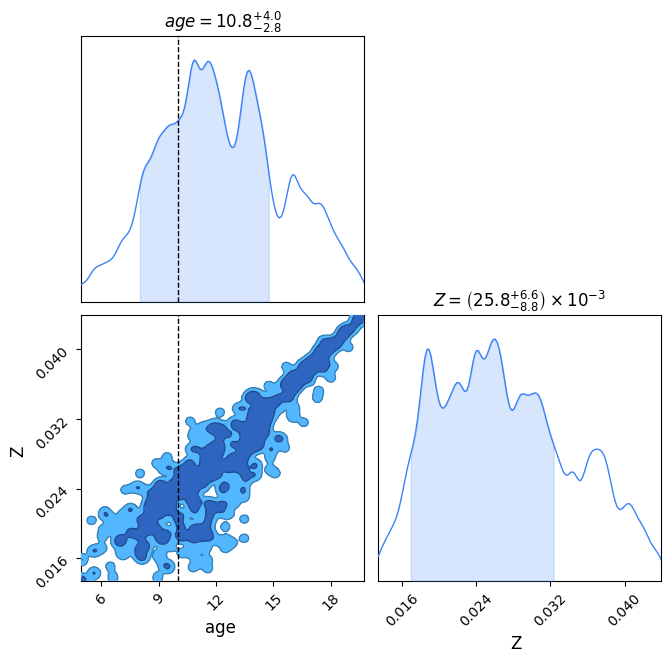

In [23]:
import pandas as pd
from chainconsumer import ChainConsumer, Chain, Truth

# 1) Draw samples from the untrained bounded flow
theta0, logq0 = model.apply(params, key=jax.random.PRNGKey(1), n_samples=500)
df = pd.DataFrame(theta0, columns=["age", "Z"])

# 2) Optional: pick a fiducial point (for synthetic tests use your known truth)
fid_age = 10.0                      # example: mid of [0, 20]
fid_Z   = 1.0e-2                    # example: inside [4.5e-5, 4.5e-2]

# 3) Build the ChainConsumer plot
c = ChainConsumer()
c.add_chain(Chain(samples=df, name="Initial VI"))
c.add_truth(Truth(location={"age": fid_age, "Z": fid_Z}))

fig = c.plotter.plot(figsize="column")


In [24]:
def log_prior_gaussian(theta_batch,
                       mu_age=10.0, sigma_age=5.0,
                       mu_Z=1e-2, sigma_Z=5e-3):
    """Gaussian prior in physical space."""
    age = theta_batch[:, 0]
    Z   = theta_batch[:, 1]
    lp_age = -0.5 * (((age - mu_age) / sigma_age)**2
                     + jnp.log(2*jnp.pi*sigma_age**2))
    lp_Z   = -0.5 * (((Z - mu_Z) / sigma_Z)**2
                     + jnp.log(2*jnp.pi*sigma_Z**2))
    return lp_age + lp_Z  # shape (batch,)


In [25]:
import jax, jax.numpy as jnp

def log_likelihood(y, s, sigma_obs, mask=None, sigma_jitter=0.0):
    """Full-vector Gaussian log-likelihood."""
    if mask is None:
        mask = jnp.ones_like(y)
    var = sigma_obs**2 + sigma_jitter**2
    r = y - s
    term = -0.5 * (r**2 / var + jnp.log(2*jnp.pi*var))
    return jnp.sum(term * mask)

def make_batched_loglik(y, sigma_obs, base_data, pipeline_instance, mask=None, sigma_jitter=0.0):
    """Returns a function mapping a batch of theta -> per-sample log-likelihood."""
    def one_theta(theta):
        age, Z = theta[0], theta[1]
        s = spectrum_1d(age, Z, base_data, pipeline_instance)  # -> (n_lambda,)
        return log_likelihood(y, s, sigma_obs, mask=mask, sigma_jitter=sigma_jitter)
    return jax.vmap(one_theta)  # (batch,2) -> (batch,)


In [26]:
def make_elbo_fn(y, sigma_obs, base_data, pipeline_instance,
                 mask=None, sigma_jitter=0.0,
                 mu_age=10.0, sigma_age=5.0,
                 mu_Z=1e-2, sigma_Z=5e-3):
    batched_loglik = make_batched_loglik(y, sigma_obs, base_data,
                                         pipeline_instance, mask, sigma_jitter)

    def elbo(params, seed, n_samples=128):
        # Draw θ ~ q_φ(θ)
        theta_batch, log_q = model.apply(params, key=seed, n_samples=n_samples)
        # Compute log p(θ)
        log_p = log_prior_gaussian(theta_batch, mu_age, sigma_age, mu_Z, sigma_Z)
        # Compute log p(y|θ)
        log_lik = batched_loglik(theta_batch)
        # ELBO
        elbo_value = jnp.mean(log_lik + log_p - log_q)
        return -elbo_value   # minimize
    return elbo


In [27]:
# Random key
seed = jax.random.PRNGKey(0)

# Scheduler and optimizer
total_steps = 2_000
lr_scheduler = optax.piecewise_constant_schedule(
    init_value=1e-3,
    boundaries_and_scales={int(total_steps*0.5): 0.2}
)
optimizer = optax.adam(lr_scheduler)
opt_state = optimizer.init(params)

# TensorBoard logs
from flax.metrics import tensorboard
summary_writer = tensorboard.SummaryWriter("logs/elbo")


In [28]:
eps = 1e-6
sigma_obs = jnp.maximum(jnp.abs(spec0) / 100.0, eps)
y = spec0
base_data = inputdata

In [29]:
# Build once, outside update_model
elbo = make_elbo_fn(
    y,                      # observed full flux vector
    sigma_obs,              # scalar or per-pixel vector
    base_data,
    pipeline_instance,      # <- the missing arg in your error
    mask=None,
    sigma_jitter=0.0,
    mu_age=10.0,  sigma_age=5.0,
    mu_Z=1e-2,   sigma_Z=5e-3
)

In [30]:

@jax.jit
def update_model(params, opt_state, seed):#, n_samples=128):
    # split RNG: first return is new seed you’ll keep, second is used to sample θ
    seed, key = jax.random.split(seed)

    # loss(params) = -ELBO(params, key, n_samples)
    loss, grads = jax.value_and_grad(elbo)(params, key)#, n_samples)

    # apply Adam step; passing params is safest for transforms that need them
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, loss, seed


In [31]:
%load_ext tensorboard
%tensorboard --logdir=.

In [32]:
import tqdm

for i in tqdm.tqdm(range(total_steps)):
    # one optimization step (minimizes -ELBO)
    params, opt_state, loss, seed = update_model(params, opt_state, seed)

    # log every 10 steps
    if i % 10 == 0:
        summary_writer.scalar("neg_elbo", float(loss), i)
        summary_writer.scalar("learning_rate", float(lr_scheduler(i)), i)


100%|██████████| 2000/2000 [02:08<00:00, 15.54it/s]


In [33]:
# 1) Sample posterior θ = (age, Z)
seed, sub = jax.random.split(seed)
theta, log_q = model.apply(params, key=sub, n_samples=5000)  # theta.shape == (5000, 2)
age = theta[:, 0]
Z   = theta[:, 1]


Parameter age in chain VI is not constrained
Parameter Z in chain VI is not constrained


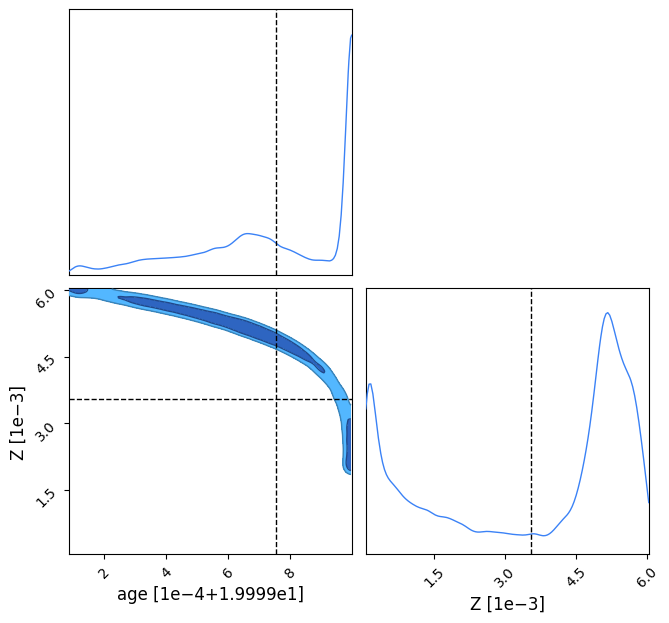

In [34]:
import numpy as np

# sample posterior
seed, sub = jax.random.split(seed)
theta, log_q = model.apply(params, key=sub, n_samples=20_000)
age = np.asarray(theta[:, 0], dtype=float)
Z   = np.asarray(theta[:, 1], dtype=float)

# physical bounds
AGE_MIN, AGE_MAX = 0.0, 20.0
Z_MIN,   Z_MAX   = 4.5e-5, 4.5e-2

# add tiny jitter if distribution is (near-)collapsed so CC can bin
def jitter_if_flat(x, span_abs, thresh=1e-12, frac=1e-6, seed=0):
    ptp = float(x.max() - x.min())
    if ptp < thresh:
        rng = np.random.default_rng(seed)
        x = x + frac * span_abs * rng.standard_normal(x.shape)
    return x

age = jitter_if_flat(age, span_abs=(AGE_MAX - AGE_MIN), thresh=1e-9,  frac=1e-6, seed=0)
Z   = jitter_if_flat(Z,   span_abs=(Z_MAX   - Z_MIN),   thresh=1e-12, frac=1e-6, seed=1)

# clip to bounds (safety)
age = np.clip(age, AGE_MIN, AGE_MAX)
Z   = np.clip(Z,   Z_MIN,   Z_MAX)

# optional: downsample for speed/robustness
if age.size > 10000:
    idx = np.random.default_rng(2).choice(age.size, size=10000, replace=False)
    age, Z = age[idx], Z[idx]

# build dataframe and plot
df = pd.DataFrame({"age": age, "Z": Z})

c = ChainConsumer()
c.add_chain(Chain(samples=df, name="VI"))
c.add_truth(Truth(location={"age": float(age.mean()), "Z": float(Z.mean())}))
fig = c.plotter.plot(figsize="column")


In [35]:
c = ChainConsumer()

# fresh RNG split so we don’t reuse training key
seed, sub = jax.random.split(seed)

# sample θ ~ qϕ(θ)
theta, log_q = model.apply(params, key=sub, n_samples=20_000)  # shape (N, 2)
age = theta[:, 0]
Z   = theta[:, 1]

# ChainConsumer expects a pandas DataFrame
df = pd.DataFrame({"age": age, "Z": Z})

# add the VI chain
c.add_chain(Chain(samples=df, name="VI"))

# optional “truth” dot: use known synthetic truth if you have it; else posterior mean
# truth_age, truth_Z = 8.0, 1.0e-2   # <- set these if you know them
truth_age, truth_Z = float(age.mean()), float(Z.mean())
c.add_truth(Truth(location={"age": truth_age, "Z": truth_Z}))

fig = c.plotter.plot(figsize="column")

ValueError: Too many bins for data range. Cannot create 2000 finite-sized bins.